# [DB금융공모전] 가중 코호트 트렌드를 활용한 헬스케어 동적 프라이싱 모델링

### 1. 데이터 전처리 및 가중 코호트(Trend) 기반 LightGBM 모델 학습
- 건보공단 데이터(3개년)를 활용하여 '또래 대비 악화 속도(Trend)' 파생 변수 생성, 당뇨 신장병증 전환(eGFR < 60)을 예측하는 기본 머신러닝 모델 구축

In [1]:
from google.colab import files
uploaded = files.upload()

Saving healthdata2022.csv to healthdata2022.csv
Saving healthdata2023.csv to healthdata2023.csv
Saving healthdata2024.CSV to healthdata2024.CSV


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 전처리 함수
# ==============================================================================
def preprocess_pipeline(df):
    # 컬럼 표준화
    col_map = {
        "성별": "SEX", "성별코드": "SEX",
        "연령대코드(5세단위)": "AGE_GROUP",
        "시도코드": "SIDO", "신장(5cm단위)": "HEIGHT", "체중(5kg단위)": "WEIGHT",
        "수축기혈압": "BP_SYS", "이완기혈압": "BP_DIA", "식전혈당(공복혈당)": "FPG",
        "요단백": "UPRO", "혈청크레아티닌": "SCR"
    }
    df = df.rename(columns=col_map)

    # 숫자형 변환 및 필수 결측 제거
    need = ["SEX","AGE_GROUP","SIDO","HEIGHT","WEIGHT","BP_SYS","BP_DIA","FPG","UPRO","SCR"]
    for c in need:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=need)

    # 이상치 방어 (Clipping)
    df["FPG"] = df["FPG"].clip(40, 500)
    df["BP_SYS"] = df["BP_SYS"].clip(60, 260)
    df["BP_DIA"] = df["BP_DIA"].clip(30, 180)
    df["UPRO"] = df["UPRO"].clip(1, 6)
    df["SCR"] = df["SCR"].clip(0.2, 15.0)

    # 파생변수: BMI, AGE_MID
    df = df[(df["HEIGHT"].between(120, 210)) & (df["WEIGHT"].between(25, 200))]
    df["BMI"] = (df["WEIGHT"] / ((df["HEIGHT"]/100)**2)).clip(10, 60)

    AGE_MID_MAP = {i: 20 + (i-5)*5 + 2 for i in range(5, 19)}
    df = df[df["AGE_GROUP"].between(5, 18)]
    df["AGE_MID"] = df["AGE_GROUP"].map(AGE_MID_MAP)

    # 당뇨 유병자 필터 (FPG >= 126)
    df = df[df["FPG"] >= 126]

    # eGFR (CKD-EPI 2021)
    is_female = (df["SEX"] == 2)
    scr_k = df["SCR"] / np.where(is_female, 0.7, 0.9)
    alpha = np.where(is_female, -0.241, -0.302)
    sex_factor = np.where(is_female, 1.012, 1.0)

    df["eGFR"] = 142 * (np.minimum(scr_k, 1)**alpha) * \
                 (np.maximum(scr_k, 1)**(-1.200)) * \
                 (0.9938**df["AGE_MID"]) * sex_factor

    return df

# ==============================================================================
# 2. 데이터 로드 및 가중 코호트 트렌드 생성
# ==============================================================================
def read_csv_safe(path):
    try: return pd.read_csv(path, encoding='cp949')
    except: return pd.read_csv(path, encoding='utf-8')

# 파일 로드
df_2022 = read_csv_safe("healthdata2022.csv")
df_2023 = read_csv_safe("healthdata2023.csv")
df_2024 = read_csv_safe("healthdata2024.CSV")

# 기본 전처리 수행
print("1차 전처리(결측제거/파생변수) 시작...")
train_2022 = preprocess_pipeline(df_2022)
train_2023 = preprocess_pipeline(df_2023)
test_2024  = preprocess_pipeline(df_2024)

# 연도 컬럼 부여
train_2022['YEAR'] = 2022
train_2023['YEAR'] = 2023
test_2024['YEAR']  = 2024

# 전체 통합
df_all = pd.concat([train_2022, train_2023, test_2024], ignore_index=True)
print(f"전체 통합 데이터 크기: {df_all.shape}")


# [NEW] 가중 코호트 트렌드 생성 함수
def add_weighted_cohort_trends(df):
    print("\n>> 가중 코호트 트렌드(Weighted Cohort Trend) 생성 중...")

    # 트렌드를 확인용 핵심 변수
    target_cols = ['FPG', 'BP_SYS', 'BP_DIA', 'SCR', 'BMI', 'eGFR']

    # 그룹핑 키 (Pseudo-Cohort Key)
    keys = ['YEAR', 'SEX', 'AGE_GROUP', 'SIDO']

    df_proc = df.copy()

    # 연도별/코호트별 평균 통계 산출
    cohort_stats = df_proc.groupby(keys)[target_cols].mean().reset_index()

    # 동일 연령대 매칭 (작년 데이터 -> 올해로, Weight 0.8)
    stats_same = cohort_stats.copy()
    stats_same['YEAR'] = stats_same['YEAR'] + 1
    stats_same = stats_same.rename(columns={col: f'prev_{col}' for col in target_cols})

    # 유입 연령대 매칭 (Aging-out 보정, Weight 0.2)
    stats_young = stats_same.copy()
    stats_young['AGE_GROUP'] = stats_young['AGE_GROUP'] + 1
    stats_young = stats_young.rename(columns={f'prev_{col}': f'prev_young_{col}' for col in target_cols})

    # 메인 데이터에 붙이기
    df_proc = pd.merge(df_proc, stats_same, on=keys, how='left')
    df_proc = pd.merge(df_proc, stats_young, on=keys, how='left')

    # 트렌드 계산
    trend_features = []
    for col in target_cols:
        prev_col = f'prev_{col}'
        prev_young_col = f'prev_young_{col}'

        # 가중 평균 (80:20 Rule)
        df_proc[f'base_{col}'] = np.where(
            df_proc[prev_young_col].notnull(),
            (df_proc[prev_col] * 0.8) + (df_proc[prev_young_col] * 0.2),
            df_proc[prev_col]
        )

        # Trend = 내 수치 - 코호트 가중평균
        new_col = f'Trend_{col}'
        df_proc[new_col] = df_proc[col] - df_proc[f'base_{col}']
        trend_features.append(new_col)

    # 결측치(2022년) 0 처리 및 정리
    df_proc[trend_features] = df_proc[trend_features].fillna(0)
    drop_cols = [c for c in df_proc.columns if c.startswith('prev_') or c.startswith('base_')]
    df_proc = df_proc.drop(columns=drop_cols)

    print(f"   -> 생성된 트렌드 변수: {trend_features}")
    return df_proc, trend_features

# 함수 적용
df_final, trend_feats = add_weighted_cohort_trends(df_all)

# Train / Test 분리
train = df_final[df_final['YEAR'].isin([2022, 2023])].copy()
test  = df_final[df_final['YEAR'] == 2024].copy()

# 타겟 정의 (Target: eGFR < 60)
train["Target"] = (train["eGFR"] < 60).astype(int)
test["Target"]  = (test["eGFR"] < 60).astype(int)

# 모델링용 변수 설정 (기존 + 트렌드)
base_features = ["SEX", "AGE_MID", "BMI", "FPG", "BP_SYS", "BP_DIA", "UPRO", "SCR"]
final_features = base_features + trend_feats

X_train, y_train = train[final_features], train["Target"]
X_test, y_test   = test[final_features], test["Target"]

print("-" * 50)
print(f"최종 데이터 준비 완료:")
print(f"Train (22+23): {X_train.shape}")
print(f"Test  (24)   : {X_test.shape}")
print(f"사용 Feature 수: {len(final_features)}개")
print("-" * 50)


# ==============================================================================
# 3. 모델 학습 (Weighted Trend 반영)
# ==============================================================================
model = lgb.LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)

# 예측 확률 (Risk Score)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Feature Importance 확인 (트렌드 변수가 얼마나 중요한지 체크)
imp_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n[Feature Importance Top 5]")
print(imp_df.head(5))
print("\n기본 모델 학습 완료")

1차 전처리(결측제거/파생변수) 시작...
전체 통합 데이터 크기: (233596, 37)

>> 가중 코호트 트렌드(Weighted Cohort Trend) 생성 중...
   -> 생성된 트렌드 변수: ['Trend_FPG', 'Trend_BP_SYS', 'Trend_BP_DIA', 'Trend_SCR', 'Trend_BMI', 'Trend_eGFR']
--------------------------------------------------
최종 데이터 준비 완료:
Train (22+23): (155768, 14)
Test  (24)   : (77828, 14)
사용 Feature 수: 14개
--------------------------------------------------
[LightGBM] [Info] Number of positive: 9070, number of negative: 146698
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2360
[LightGBM] [Info] Number of data points in the train set: 155768, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058228 -> initscore=-2.783404
[LightGBM] [Info] Start training from score -2.783404

[Feature Importance Top 5]
      Feature  Importan

### 2. [A안]FN 최소화를 위한 예측 임계값 하향 조정
- 당뇨병성 신장질환으로 인한 비용 발생 방지,
잠재적 고위험군을 놓치는 비용 방어와 이를 위한 보수적 임계값 조정

=== [A안] FN 최소화 전략 (Threshold: 0.3) ===
놓친 고위험군 환자 수 (FN): 0명
고위험군 탐지율 (Recall): 100.00%
------------------------------


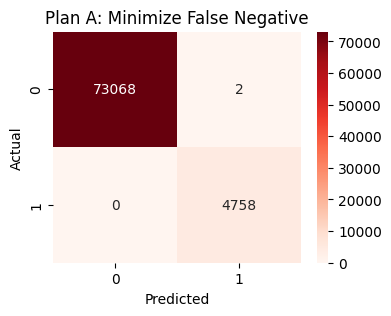

In [4]:
# ---------------------------------------------------------
# A안: 보수적 접근 (보험사 리스크 최소화)
# 전략: Threshold를 낮춰서 실제 환자(Positive)를 최대한 많이 잡아냄
# ---------------------------------------------------------

threshold_A = 0.3  # 민감도를 높이기 위해 임계값 하향
y_pred_A = (y_pred_proba >= threshold_A).astype(int)

# 평가
cm = confusion_matrix(y_test, y_pred_A)
tn, fp, fn, tp = cm.ravel()

print(f"=== [A안] FN 최소화 전략 (Threshold: {threshold_A}) ===")
print(f"놓친 고위험군 환자 수 (FN): {fn}명")
print(f"고위험군 탐지율 (Recall): {tp / (tp + fn):.2%}")
print("-" * 30)

# 시각화
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Plan A: Minimize False Negative")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 3. [B안]예산 한계 반영: Top-K 기반 고위험군(상위 7%) 집중 타겟팅
- 임계값 하향으로 인해 관리 대상자(FP) 급증, 한정된 예산 내의 최대 효율 탐색

=== [B안] Top-7% 타겟팅 전략 ===
관리 대상 인원: 5447명 (전체의 7%)
대상 내 실제 환자 포착 수: 4758명 / 전체 4758명
Capture Rate (적중률): 100.00%


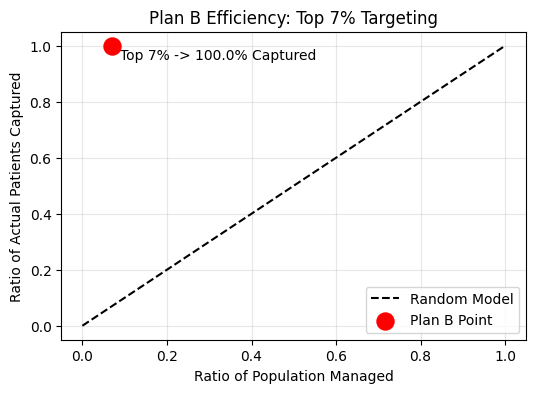

In [5]:
# ---------------------------------------------------------
# B안: 실무적 접근 (Top-K Targeting)
# 전략: 예산 한계로 인해 상위 7%만 집중 관리 대상으로 선정
# ---------------------------------------------------------

# 예측 확률 기준 내림차순 정렬
test_results = test.copy()
test_results["Risk_Score"] = y_pred_proba
test_results = test_results.sort_values("Risk_Score", ascending=False)

# Top 7% 끊기
top_k_percent = 0.07
cutoff_index = int(len(test_results) * top_k_percent)
top_k_group = test_results.iloc[:cutoff_index]

# 성과 분석
captured_patients = top_k_group["Target"].sum() # 상위 그룹 내 실제 환자 수
total_patients = test_results["Target"].sum()   # 전체 실제 환자 수
capture_rate = captured_patients / total_patients

print(f"=== [B안] Top-{top_k_percent*100:.0f}% 타겟팅 전략 ===")
print(f"관리 대상 인원: {len(top_k_group)}명 (전체의 {top_k_percent*100:.0f}%)")
print(f"대상 내 실제 환자 포착 수: {captured_patients}명 / 전체 {total_patients}명")
print(f"Capture Rate (적중률): {capture_rate:.2%}")

# 리프트 차트 스타일 시각화
plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--', label="Random Model")
plt.scatter(top_k_percent, capture_rate, color='red', s=150, zorder=5, label="Plan B Point")
plt.text(top_k_percent+0.02, capture_rate-0.05, f"Top {top_k_percent*100:.0f}% -> {capture_rate*100:.1f}% Captured")
plt.title(f"Plan B Efficiency: Top {top_k_percent*100:.0f}% Targeting")
plt.xlabel("Ratio of Population Managed")
plt.ylabel("Ratio of Actual Patients Captured")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4. 하이브리드 전략 및 KneeCurve 기반 총비용 최적화
- 예방 관리 비용과 놓친 위험의 손실 비용 간의 trade-off, 총 비용 최적화 곡선을 통한 타겟팅 범위 증명

=== Hybrid Simulation Start (Data: 22+23 Train / 24 Test) ===
eGFR < 60 완료 | 위험군 비율: 6.1% | 놓친 비율: 0.0%
eGFR < 65 완료 | 위험군 비율: 9.2% | 놓친 비율: 23.8%
eGFR < 70 완료 | 위험군 비율: 12.8% | 놓친 비율: 45.2%
eGFR < 74 완료 | 위험군 비율: 17.7% | 놓친 비율: 60.5%
eGFR < 75 완료 | 위험군 비율: 18.1% | 놓친 비율: 61.4%
eGFR < 76 완료 | 위험군 비율: 20.6% | 놓친 비율: 66.0%
eGFR < 77 완료 | 위험군 비율: 20.9% | 놓친 비율: 66.6%
eGFR < 80 완료 | 위험군 비율: 25.3% | 놓친 비율: 72.3%


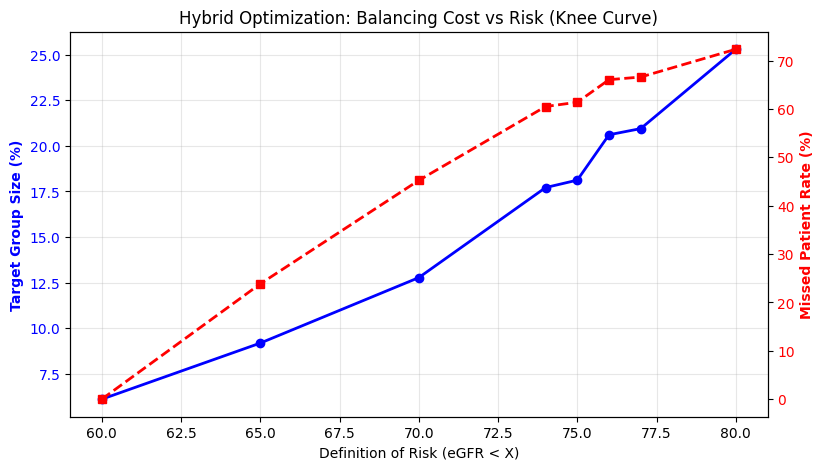

해석: 파란선(관리대상)이 급증하기 직전이면서, 빨간선(놓친비율)이 충분히 낮은 지점이 최적의 타협점입니다.


In [6]:
# ---------------------------------------------------------
# 하이브리드안: Knee Curve를 통한 최적 타겟 기준 탐색
# 시나리오: eGFR 기준(60, 65, 70, 74, 75, 80) 변경 시 "놓친 위험(FN)" vs "관리 비용(대상자 수)" 변화
# ---------------------------------------------------------

cutoffs = [60, 65, 70, 74, 75, 76, 77, 80]
results = []

print("=== Hybrid Simulation Start (Data: 22+23 Train / 24 Test) ===")

for cut in cutoffs:
    # 타겟 재정의 (Ground Truth 변경)
    y_train_new = (train["eGFR"] < cut).astype(int)
    y_test_new = (test["eGFR"] < cut).astype(int)

    # 재학습
    model_hybrid = lgb.LGBMClassifier(random_state=42, n_estimators=100, verbose=-1)
    model_hybrid.fit(X_train, y_train_new)

    # 예측 및 Top-7% 적용 가정 시 성과 측정
    probs = model_hybrid.predict_proba(X_test)[:, 1]

    # 상위 7% 선정
    n_top = int(len(test) * 0.07)
    top_indices = np.argsort(probs)[::-1][:n_top]

    # FN 계산 (Top 7% 밖의 실제 환자)
    pred_labels = np.zeros(len(test))
    pred_labels[top_indices] = 1 # Top 7%만 관리

    # Confusion Matrix 요소 추출
    tn, fp, fn, tp = confusion_matrix(y_test_new, pred_labels).ravel()

    target_prevalence = y_test_new.mean() # 실제 위험군 비율

    results.append({
        "Threshold_eGFR": cut,
        "Target_Prevalence": target_prevalence * 100, # % 단위
        "Missed_Rate": fn / (y_test_new.sum()) * 100  # 전체 환자 중 놓친 비율 (%)
    })
    print(f"eGFR < {cut} 완료 | 위험군 비율: {target_prevalence:.1%} | 놓친 비율: {fn / (y_test_new.sum()):.1%}")

# Knee Curve 시각화
res_df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(9, 5))

# X축: eGFR 기준
x = res_df['Threshold_eGFR']

# Y축 1: 관리 대상이 되어야 할 실제 위험군 규모 (Target Size) -> 비용(Cost) 관점
ax1.set_xlabel('Definition of Risk (eGFR < X)')
ax1.set_ylabel('Target Group Size (%)', color='blue', fontweight='bold')
ax1.plot(x, res_df['Target_Prevalence'], 'b-o', linewidth=2, label='Risk Population Size')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Y축 2: 놓친 환자 비율 (Missed Rate) -> 리스크(Risk) 관점
ax2 = ax1.twinx()
ax2.set_ylabel('Missed Patient Rate (%)', color='red', fontweight='bold')
ax2.plot(x, res_df['Missed_Rate'], 'r--s', linewidth=2, label='Missed Rate (Risk)')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Hybrid Optimization: Balancing Cost vs Risk (Knee Curve)")
plt.show()

print("해석: 파란선(관리대상)이 급증하기 직전이면서, 빨간선(놓친비율)이 충분히 낮은 지점이 최적의 타협점입니다.")

#### 5. XAI(설명 가능한 AI) SHAP 알고리즘을 활용한 핵심 요인 검증
- 블랙박스 모델 방지를 위한 SHAP Value 추출 및 시각적 검증

=== Feature Importance (SHAP Summary) ===


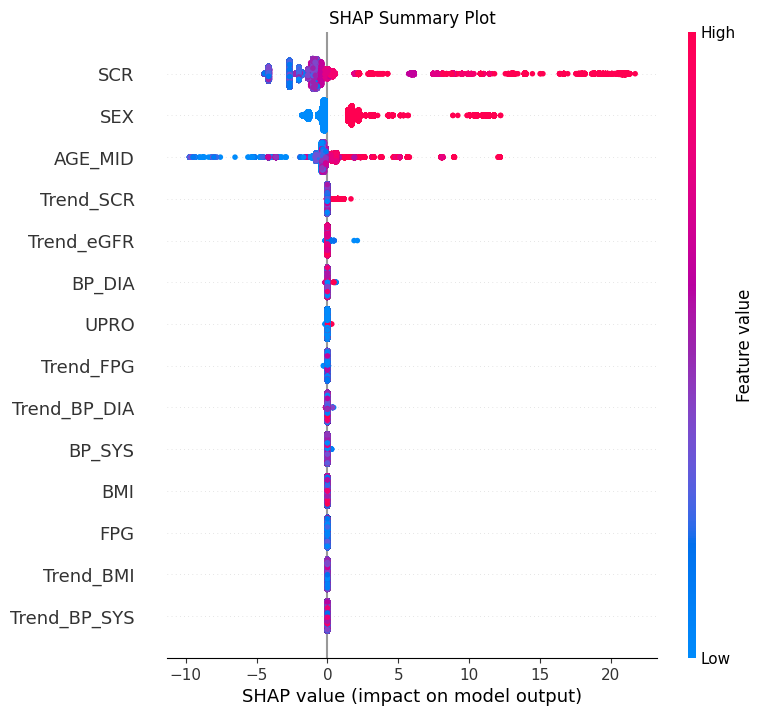

=== Dependence Plot: SCR ===
SCR(가로축)이 증가할수록 위험도(세로축)가 어떻게 변하는지 보여줍니다.


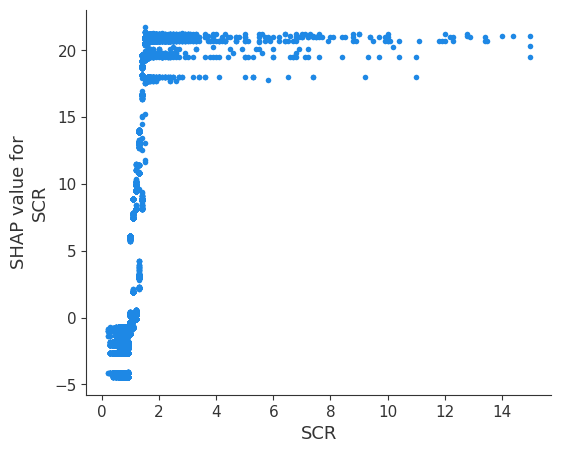

In [7]:
# ---------------------------------------------------------
# SHAP 분석
# ---------------------------------------------------------
import shap

# Cell 1에서 학습한 기본 모델(model) 활용
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# LightGBM의 경우 shap_values가 리스트로 반환될 수 있음 (Binary Class)
if isinstance(shap_values, list):
    shap_vals_target = shap_values[1] # Positive Class(위험군)에 대한 기여도
else:
    shap_vals_target = shap_values

# Summary Plot (전체 변수 중요도 및 영향 방향)
print("=== Feature Importance (SHAP Summary) ===")
plt.figure()
shap.summary_plot(shap_vals_target, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.show()

# Dependence Plot (SCR: 크레아티닌 수치에 따른 위험도 변화)
print("=== Dependence Plot: SCR ===")
print("SCR(가로축)이 증가할수록 위험도(세로축)가 어떻게 변하는지 보여줍니다.")
shap.dependence_plot("SCR", shap_vals_target, X_test, interaction_index=None)

### 6. 비용 최적화 시뮬레이션: KneeCurve 기반 최적 타겟팅 도출
- 총 비용 최소화 타겟팅 비율 시뮬레이션 및 비용 곡선 시각화

 [시뮬레이션 결과]
 최적 관리 비율 (Top K%): 상위 7%
 이때의 최소 총 비용: 1,089,400,000 원


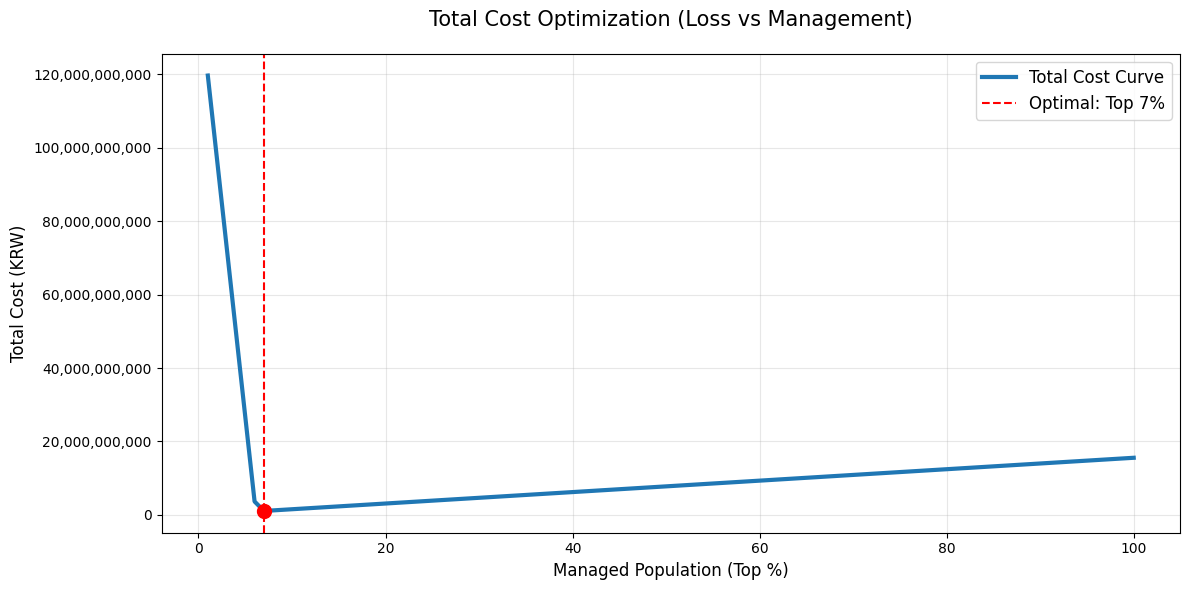

In [8]:
# ==========================================
# 1. 비용 파라미터 설정
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# C_manage: 관리 비용 (앱 구독료 + 정밀검사비) = 20만원
COST_MANAGE = 200000
# L_loss: 손실 비용 (투석비용 등) = 3,000만원
COST_LOSS = 30000000

# ==========================================
# 2. 비용 최적화 시뮬레이션 함수 정의
# ==========================================
def calculate_optimal_threshold(y_true, y_prob):
    # 데이터를 확률 내림차순으로 정렬
    df_sim = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df_sim = df_sim.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

    total_users = len(df_sim)
    total_positives = df_sim['y_true'].sum() # 전체 실제 환자 수

    records = []

    # 상위 1%부터 100%까지 1% 단위로 끊어서 비용 계산
    for k in range(1, 101):
        # 상위 k% 지점의 인원 수
        cutoff_idx = int(total_users * (k / 100))

        # 관리 대상자 수 (TP + FP) -> 상위 k% 인원 전체
        n_managed = cutoff_idx

        # 놓친 환자 수 (FN) -> 관리 대상이 아닌 사람들 중 실제 환자 수
        n_missed_risk = df_sim.iloc[cutoff_idx:]['y_true'].sum()

        # 총 비용 계산 공식
        # Total Cost = (관리대상 수 * 관리비용) + (놓친환자 수 * 손실비용)
        total_cost = (n_managed * COST_MANAGE) + (n_missed_risk * COST_LOSS)

        records.append({
            'Top_K_Percent': k,
            'Total_Cost': total_cost,
            'Managed_Count': n_managed,
            'Missed_Risk_Count': n_missed_risk
        })

    return pd.DataFrame(records)

# ==========================================
# 3. 시뮬레이션 실행
# ==========================================
# y_test: 실제값, y_pred_proba: 모델 예측 확률값

df_cost_curve = calculate_optimal_threshold(y_test.values, y_pred_proba)

# 최적 지점 찾기 (비용이 가장 낮은 지점)
optimal_point = df_cost_curve.loc[df_cost_curve['Total_Cost'].idxmin()]
opt_k = optimal_point['Top_K_Percent']
opt_cost = optimal_point['Total_Cost']

print(f"========================================================")
print(f" [시뮬레이션 결과]")
print(f" 최적 관리 비율 (Top K%): 상위 {opt_k}%")
print(f" 이때의 최소 총 비용: {opt_cost:,.0f} 원")
print(f"========================================================")

# ==========================================
# 4. 시각화 (U자형 곡선 그리기)
# ==========================================
plt.figure(figsize=(12, 6))

# 비용 곡선 (Total Cost)
sns.lineplot(data=df_cost_curve, x='Top_K_Percent', y='Total_Cost',
             linewidth=3, color='#1f77b4', label='Total Cost Curve')

# 최적점 표시 (빨간 점선 & 텍스트)
plt.axvline(x=opt_k, color='red', linestyle='--', linewidth=1.5, label=f'Optimal: Top {opt_k}%')
plt.scatter(opt_k, opt_cost, color='red', s=100, zorder=5)

# 그래프 꾸미기
plt.title('Total Cost Optimization (Loss vs Management)', fontsize=15, pad=20)
plt.xlabel('Managed Population (Top %)', fontsize=12)
plt.ylabel('Total Cost (KRW)', fontsize=12)
plt.grid(True, alpha=0.3)

# 금액 단위 보기 좋게 포맷팅 (y축)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

>> [등급별 보험료, 보장금액 및 리스크 현황]


,Count,Avg_Premium,Coverage,Actual_Risk,Total_Mgmt_Cost
Risk_Grade,,,,,
Grade A (우수),52362,45000.0,30000000.0,0.000000,2094480000
Grade B (보통),20014,50000.0,15000000.0,0.000000,800560000
Grade C (위험),5452,90000.0,5000000.0,0.872707,1090400000


---------------------------------------------------------------------------
>> [가입 1년 차 예상 재무 시뮬레이션 (전체 고객 기준)]
1. 총 예상 보험료 수익: 46,172,040,000 원
2. 총 예상 보장 지급액: 23,790,000,000 원
3. 총 예상 관리 비용  : 3,985,440,000 원
   => 최종 예상 순수익: 18,396,600,000 원 (흑자/적자 확인)
---------------------------------------------------------------------------
>> [고객 맞춤형 안내 메시지 예시 (앱 푸시알림용)]
[Grade A (우수)] 고객님
 - 월 보험료: 45,000원  /  초기 보장: 3,000만 원
 - 안내 메시지: 꾸준한 관리로 수치가 안정적입니다. (초기 보장 3,000만 원 확정)
----------------------------------------
[Grade B (보통)] 고객님
 - 월 보험료: 50,000원  /  초기 보장: 1,500만 원
 - 안내 메시지: 현재 수치는 표준이나 지속 모니터링이 필요합니다. (1년 건강 유지 시 보장 3,000만 원으로 상향)
----------------------------------------
[Grade C (위험)] 고객님
 - 월 보험료: 90,000원  /  초기 보장: 500만 원
 - 안내 메시지: 주의: 또래 대비 '신장 기능 저하 속도'가 1.0배 빠릅니다. 1년 집중 관리 개선 시 보장 1,500만 원으로 상향!
----------------------------------------


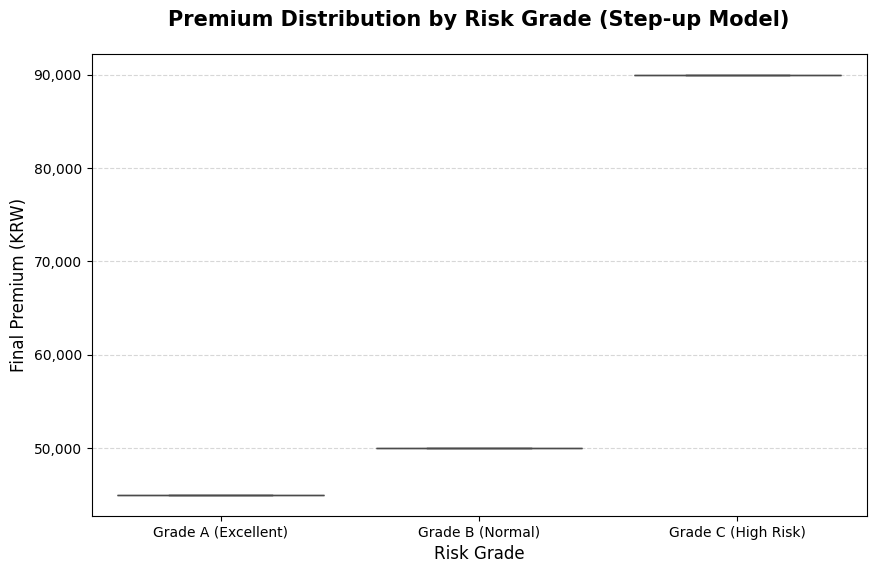

In [9]:
# ==============================================================================
# [최종] 성과 기반 동적 프라이싱 & 보장 체증형 재무 시뮬레이션
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 준비 (Test 데이터 기준)
df_pricing = test.copy()
df_pricing['Pred_Prob'] = y_pred_proba  # 모델 예측 확률 (Risk Score)

# ---------------------------------------------------------
# Step 1. 등급 산정 (Top 7% 전략 반영)
# ---------------------------------------------------------
# - Grade A (우수): 하위 60% (관리 잘함)
# - Grade B (보통): 상위 7~40% (주의 필요)
# - Grade C (위험): 상위 7% (집중 관리)

th_safe = df_pricing['Pred_Prob'].quantile(0.60)   # 하위 60%
th_danger = df_pricing['Pred_Prob'].quantile(0.93) # 상위 7% (0.93 지점)

def assign_grade(prob):
    if prob <= th_safe: return 'Grade A (우수)'
    elif prob >= th_danger: return 'Grade C (위험)'
    else: return 'Grade B (보통)'

df_pricing['Risk_Grade'] = df_pricing['Pred_Prob'].apply(assign_grade)

# ---------------------------------------------------------
# Step 2. 보험료, 초기 보장금액, 관리비용 산출 (보장 체증형 적용)
# ---------------------------------------------------------
base_premium = 50000  # 기준 보험료

# 1) 등급별 승수 (A: 4.5만, B: 5만, C: 9만)
grade_multiplier = {
    'Grade A (우수)': 0.9,   # 45,000원
    'Grade B (보통)': 1.0,   # 50,000원
    'Grade C (위험)': 1.8    # 90,000원
}

# 2) 초기 보장 금액 (가입 1년 차 - 역선택 방어용)
coverage_map = {
    'Grade A (우수)': 30000000, # 3,000만 원
    'Grade B (보통)': 15000000, # 1,500만 원
    'Grade C (위험)': 5000000   # 500만 원
}

# 3) 연간 1인당 관리 비용 (디지털 앱 vs 전담 코칭)
mgmt_cost_map = {
    'Grade A (우수)': 40000,    # 4만 원 (AI 앱, 만보기 등)
    'Grade B (보통)': 40000,    # 4만 원 (AI 앱, 만보기 등)
    'Grade C (위험)': 200000    # 20만 원 (전담 코칭 집중 관리)
}

df_pricing['Multiplier'] = df_pricing['Risk_Grade'].map(grade_multiplier)
df_pricing['Final_Premium'] = base_premium * df_pricing['Multiplier']
df_pricing['Initial_Coverage'] = df_pricing['Risk_Grade'].map(coverage_map)
df_pricing['Mgmt_Cost'] = df_pricing['Risk_Grade'].map(mgmt_cost_map)

# ---------------------------------------------------------
# Step 3. Reason Code 생성
# ---------------------------------------------------------
# 주요 Trend 변수들의 전체 평균(Mean)과 표준편차(Std) 계산
trend_cols = ['Trend_FPG', 'Trend_SCR', 'Trend_BMI']
stats = df_pricing[trend_cols].agg(['mean', 'std']).to_dict()

def generate_reason(row):
    if row['Risk_Grade'] == 'Grade A (우수)':
        return "꾸준한 관리로 수치가 안정적입니다. (초기 보장 3,000만 원 확정)"

    if row['Risk_Grade'] == 'Grade B (보통)':
        return "현재 수치는 표준이나 지속 모니터링이 필요합니다. (1년 건강 유지 시 보장 3,000만 원으로 상향)"

    worst_factor = ""
    max_z = -1
    reason_map = {'Trend_FPG': '혈당 악화 속도', 'Trend_SCR': '신장 기능 저하 속도', 'Trend_BMI': '비만도 증가'}

    for col in trend_cols:
        diff = row[col] - stats[col]['mean']
        z_score = diff / stats[col]['std']
        if z_score > max_z:
            max_z = z_score
            worst_factor = col

    if max_z > 0:
        factor_name = reason_map.get(worst_factor, worst_factor)
        return f"주의: 또래 대비 '{factor_name}'가 {max_z:.1f}배 빠릅니다. 1년 집중 관리 개선 시 보장 1,500만 원으로 상향!"
    else:
        return "고위험군으로 분류되었습니다. 당사의 집중 관리 프로그램에 참여하여 보장 금액을 늘려보세요."

df_pricing['Reason_Message'] = df_pricing.apply(generate_reason, axis=1)

# ---------------------------------------------------------
# Step 4. 결과 리포트 및 예상 1년차 재무 시뮬레이션
# ---------------------------------------------------------

# 등급별 통계
summary = df_pricing.groupby('Risk_Grade').agg(
    Count=('Risk_Grade', 'count'),
    Avg_Premium=('Final_Premium', 'mean'),
    Coverage=('Initial_Coverage', 'mean'),
    Actual_Risk=('Target', 'mean'), # 실제 사고 발생 확률
    Total_Mgmt_Cost=('Mgmt_Cost', 'sum')
)

print(">> [등급별 보험료, 보장금액 및 리스크 현황]")
display(summary) # 콘솔 환경일 경우 print(summary) 사용
print("-" * 75)

# 1년 단위 재무 시뮬레이션
total_annual_premium = (df_pricing['Final_Premium'] * 12).sum()
total_claims = (df_pricing['Target'] * df_pricing['Initial_Coverage']).sum() # 실제 사고자수 * 보장금액
total_mgmt_cost = df_pricing['Mgmt_Cost'].sum()
net_profit = total_annual_premium - total_claims - total_mgmt_cost

print(">> [가입 1년 차 예상 재무 시뮬레이션 (전체 고객 기준)]")
print(f"1. 총 예상 보험료 수익: {total_annual_premium:,.0f} 원")
print(f"2. 총 예상 보장 지급액: {total_claims:,.0f} 원")
print(f"3. 총 예상 관리 비용  : {total_mgmt_cost:,.0f} 원")
print(f"   => 최종 예상 순수익: {net_profit:,.0f} 원 (흑자/적자 확인)")
print("-" * 75)

# 고객 맞춤형 안내문 샘플
print(">> [고객 맞춤형 안내 메시지 예시 (앱 푸시알림용)]")
sample_users = df_pricing.groupby('Risk_Grade', observed=False).apply(lambda x: x.sample(1)).reset_index(drop=True)

for idx, row in sample_users.iterrows():
    print(f"[{row['Risk_Grade']}] 고객님")
    print(f" - 월 보험료: {int(row['Final_Premium']):,}원  /  초기 보장: {int(row['Initial_Coverage']//10000):,}만 원")
    print(f" - 안내 메시지: {row['Reason_Message']}")
    print("-" * 40)

# ==============================================================================
# Step 5. 시각화 (English Version)
# ==============================================================================

grade_map_en = {
    'Grade A (우수)': 'Grade A (Excellent)',
    'Grade B (보통)': 'Grade B (Normal)',
    'Grade C (위험)': 'Grade C (High Risk)'
}

df_pricing['Risk_Grade_En'] = df_pricing['Risk_Grade'].map(grade_map_en)

plt.figure(figsize=(10, 6))

my_palette = {
    'Grade A (Excellent)': '#2ecc71',
    'Grade B (Normal)': '#f1c40f',
    'Grade C (High Risk)': '#e74c3c'
}
order_list = ['Grade A (Excellent)', 'Grade B (Normal)', 'Grade C (High Risk)']

sns.boxplot(data=df_pricing, x='Risk_Grade_En', y='Final_Premium',
            palette=my_palette, order=order_list)

plt.title('Premium Distribution by Risk Grade (Step-up Model)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Risk Grade', fontsize=12)
plt.ylabel('Final Premium (KRW)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.show()